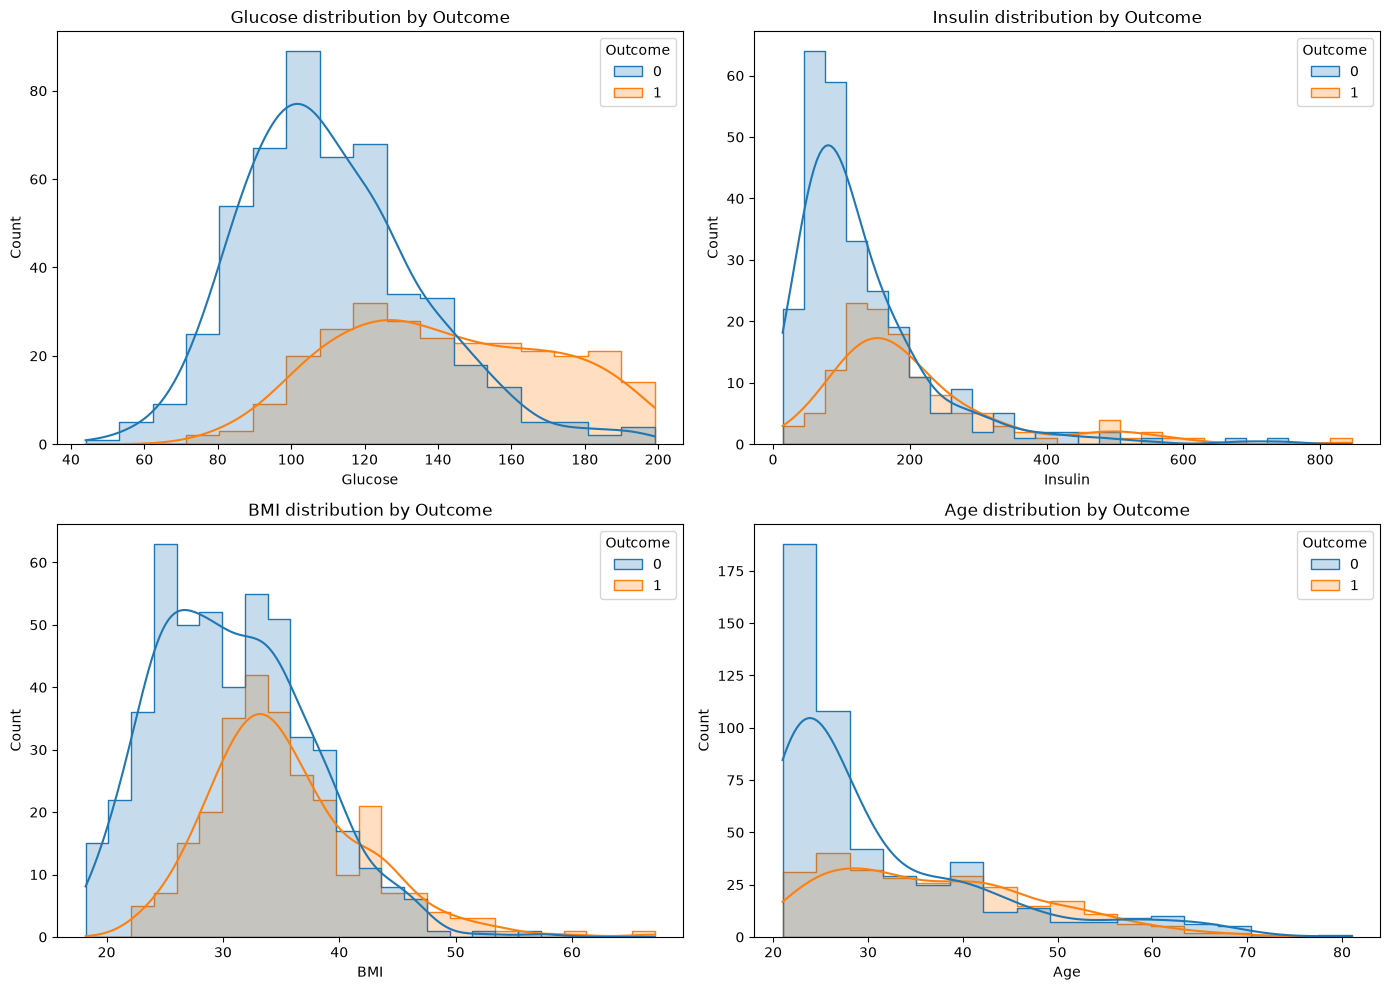


Insulin skewness: raw = 2.166 | log1p = -0.088

Outlier analysis:
Pregnancies: bounds [-6.5, 13.5], outliers: 4
Glucose: bounds [36.0, 204.0], outliers: 0
BloodPressure: bounds [40.0, 104.0], outliers: 14
SkinThickness: bounds [1.0, 57.0], outliers: 3
Insulin: bounds [-94.4, 360.6], outliers: 24
BMI: bounds [13.8, 50.2], outliers: 8
DiabetesPedigreeFunction: bounds [-0.3, 1.2], outliers: 29
Age: bounds [-1.5, 66.5], outliers: 9


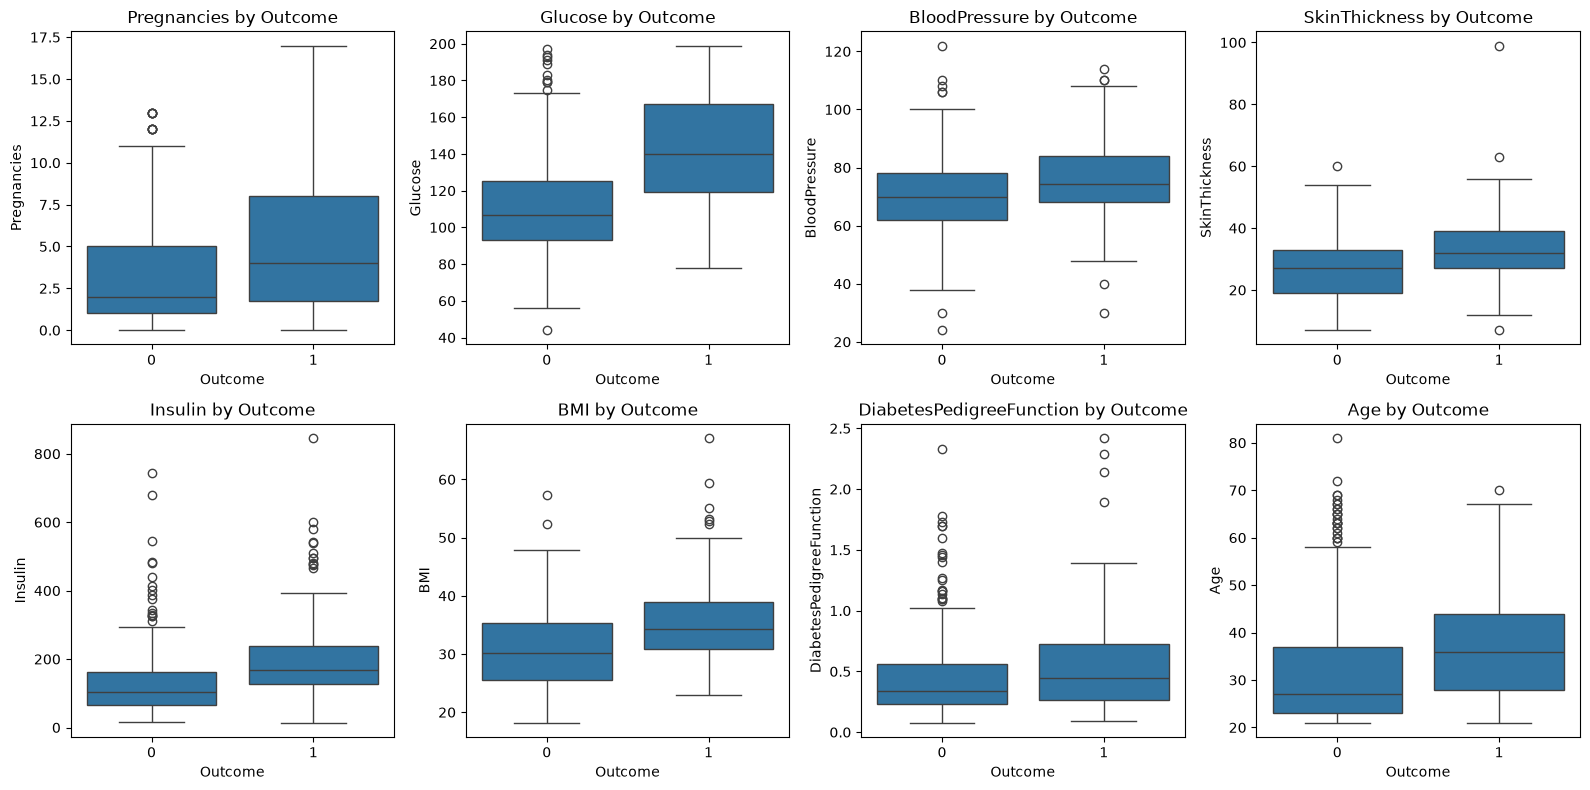

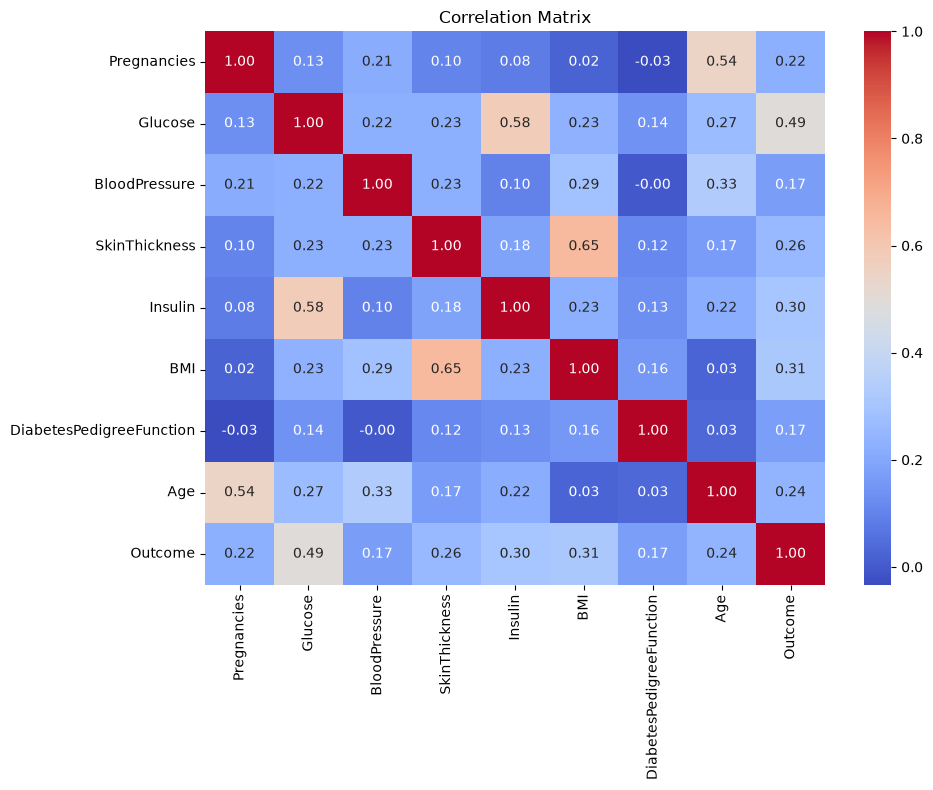

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = '../data/pima-indians-diabetes.csv'

columns = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
    'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

df = pd.read_csv(DATA_PATH, names=columns)

cols_with_zeros = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

features = ['Glucose', 'Insulin', 'BMI', 'Age']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feat in zip(axes.flatten(), features):
    sns.histplot(
        data=df,
        x=feat,
        hue='Outcome',
        kde=True,
        element='step',
        ax=ax
    )
    ax.set_title(f'{feat} distribution by Outcome')

plt.tight_layout()
plt.show()

print(
    "\nInsulin skewness: raw =",
    round(df['Insulin'].skew(), 3),
    "| log1p =",
    round(np.log1p(df['Insulin']).skew(), 3)
)

numeric_features = columns[:-1]

print("\nOutlier analysis:")

for col in numeric_features:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1

    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr

    n_out = ((df[col] < lo) | (df[col] > hi)).sum()

    print(
        f"{col}: "
        f"bounds [{lo:.1f}, {hi:.1f}], "
        f"outliers: {n_out}"
    )

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, feature in zip(axes, numeric_features):
    sns.boxplot(
        data=df,
        x='Outcome',
        y=feature,
        ax=ax
    )
    ax.set_title(f'{feature} by Outcome')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()